In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from diptest import diptest
from scipy import stats
import seaborn as sns

# Initially Exploring the Dataset

In [150]:
df = pd.read_csv('data/raw/shopping.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,3475,NaN,Male,Jacket,30.904467,Maine,M,Burnt orange,Fall,4.0,Standard,No,0,Credit Card,NaN
1,3698,21.0,Female,Backpack,31.588259,NaN,L,Turquoise,Winter,2.0,Express,No,1,Credit Card,Monthly
2,2756,31.0,Male,Leggings,24.231704,Nevada,M,Terra cotta,Winter,4.0,Standard,No,0,Credit Card,NaN
3,3340,NaN,Male,Pajamas,33.918834,Nebraska,M,Black,Winter,NaN,Standard,No,2,Credit Card,Bi-Weekly
4,3391,38.0,Male,Sunglasses,36.545487,Oregon,S,Aubergine,Summer,NaN,Standard,No,0,Credit Card,NaN


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3510 non-null   float64
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Purchase Amount (USD)   3900 non-null   float64
 5   Location                3510 non-null   object 
 6   Size                    3900 non-null   object 
 7   Color                   3900 non-null   object 
 8   Season                  3900 non-null   object 
 9   Review Rating           1431 non-null   float64
 10  Shipping Type           3900 non-null   object 
 11  Promo Code Used         3900 non-null   object 
 12  Previous Purchases      3900 non-null   int64  
 13  Payment Method          3900 non-null   object 
 14  Frequency of Purchases  1560 non-null   

In [47]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3510.000000,3900.000000,1431.000000,3900.000000
mean,1950.500000,34.256695,38.708329,3.904962,5.841538
std,1125.977353,10.616340,11.504923,1.105952,5.843695
min,1.000000,18.000000,11.392520,1.000000,0.000000
25%,975.750000,26.000000,29.332617,4.000000,1.000000
50%,1950.500000,33.000000,36.953004,4.000000,4.000000
75%,2925.250000,41.000000,48.739596,5.000000,9.000000
max,3900.000000,75.000000,69.567481,5.000000,20.000000


# Answering Required Analytical Questions

## Most Popular Colors by Season

Let's figure out what are the most popular colors by season.

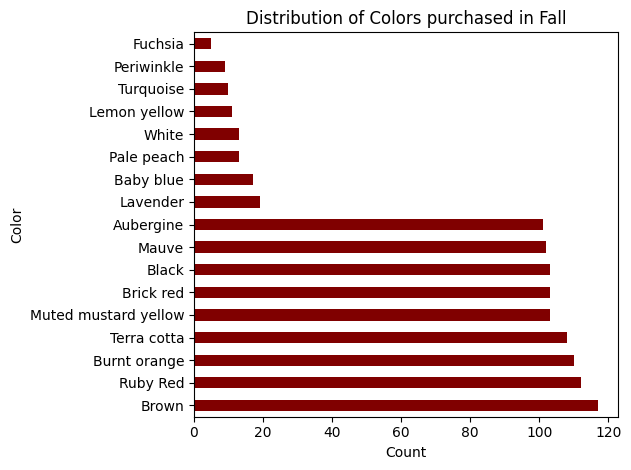

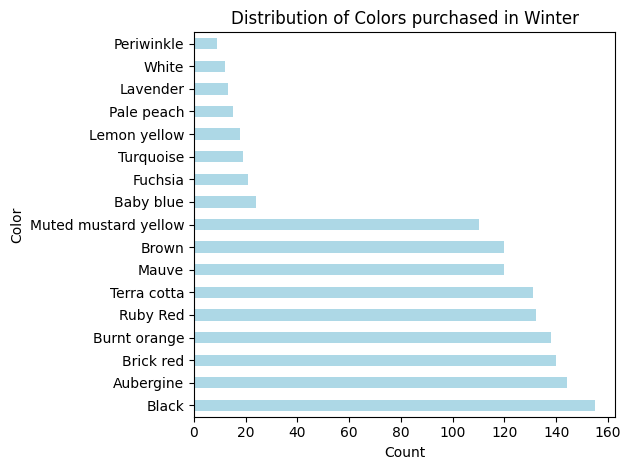

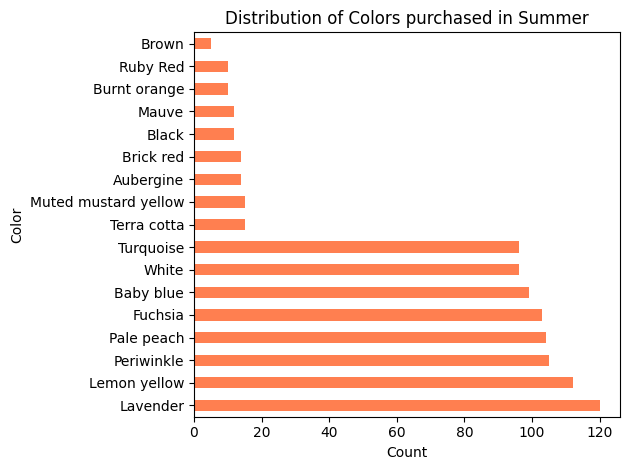

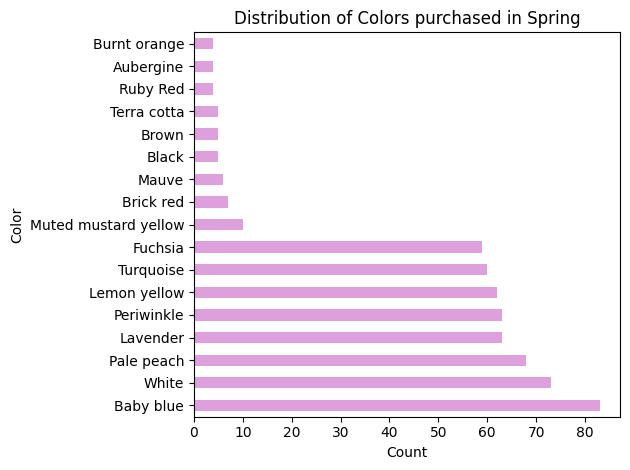

In [48]:
colors = ['maroon', 'lightblue', 'coral', 'plum']

for i, season in enumerate(df['Season'].unique()):
    season_colors = df['Color'][df['Season'] == season].value_counts()
    
    plt.figure()
    season_colors.plot(kind='barh', color=colors[i])
    plt.title(f'Distribution of Colors purchased in {season}')
    plt.xlabel('Count')
    plt.tight_layout()
    plt.show()

In [49]:
print('It looks like the top 5 colors per season are:')
for season in df['Season'].unique():
    colors = [color for color in df['Color'][df['Season'] == season].value_counts()[:5].index]
    print(f"{', '.join(colors)} in the {season}") 

It looks like the top 5 colors per season are:
Brown, Ruby Red, Burnt orange, Terra cotta, Muted mustard yellow in the Fall
Black, Aubergine, Brick red, Burnt orange, Ruby Red in the Winter
Lavender, Lemon yellow, Periwinkle, Pale peach, Fuchsia in the Summer
Baby blue, White, Pale peach, Lavender, Periwinkle in the Spring


## Most Popular Clothing Item per Season

Let's see what the most popular clothing items are per season.

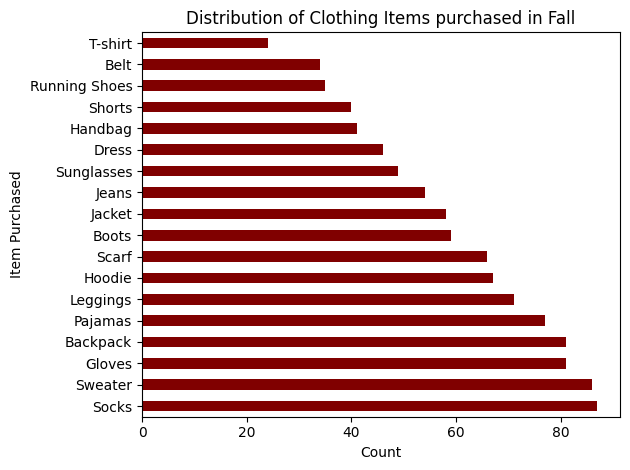

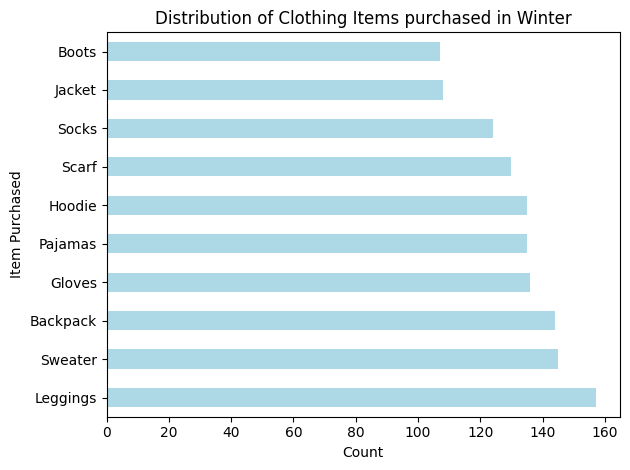

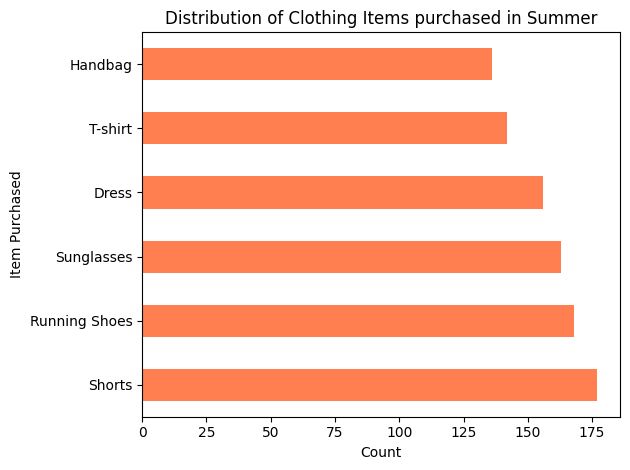

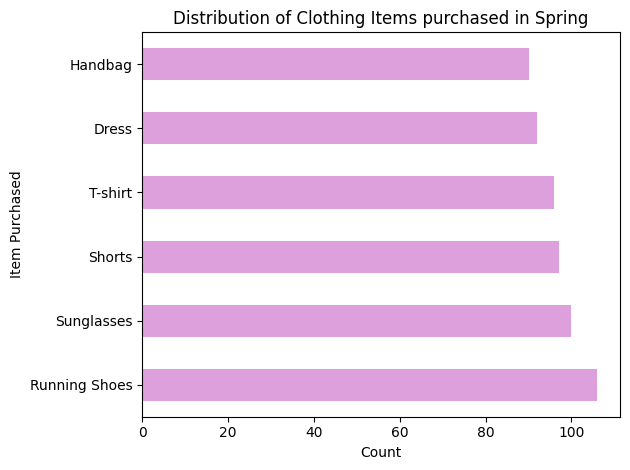

In [50]:
colors = ['maroon', 'lightblue', 'coral', 'plum']

for i, season in enumerate(df['Season'].unique()):
    season_colors = df['Item Purchased'][df['Season'] == season].value_counts()
    
    plt.figure()
    season_colors.plot(kind='barh', color=colors[i])
    plt.title(f'Distribution of Clothing Items purchased in {season}')
    plt.xlabel('Count')
    plt.tight_layout()
    plt.show()

In [66]:
print('It looks like the top clothing item per season is:')
for season in df['Season'].unique():
    print(f"{df['Item Purchased'][df['Season'] == season].value_counts().index[0]} in the {season}") 

It looks like the top clothing item per season is:
Socks in the Fall
Leggings in the Winter
Shorts in the Summer
Running Shoes in the Spring


## The Effect of Promo Codes on Purchase Dollar Amounts

Let's look into the effects of promo codes on purchase amounts

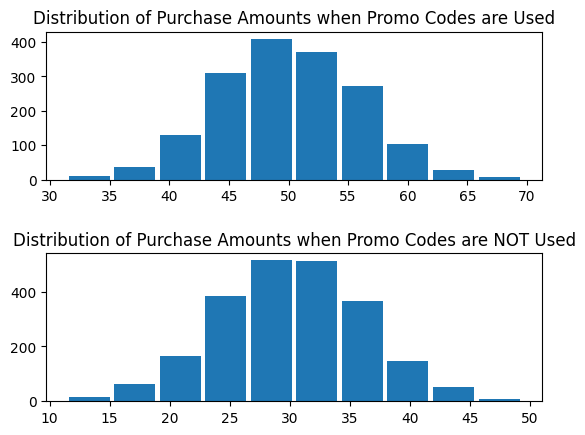

In [118]:
no_promo_df = df['Purchase Amount (USD)'][df['Promo Code Used'] == 'No']
yes_promo_df = df['Purchase Amount (USD)'][df['Promo Code Used'] == 'Yes']

fig, ax = plt.subplots(2,1)
plt.subplots_adjust(hspace=0.5)
ax[0].set_title('Distribution of Purchase Amounts when Promo Codes are Used')
ax[0].hist(yes_promo_df, rwidth=0.9, align='mid')
ax[1].set_title('Distribution of Purchase Amounts when Promo Codes are NOT Used')
ax[1].hist(no_promo_df, rwidth=0.9, align='mid')
plt.show()

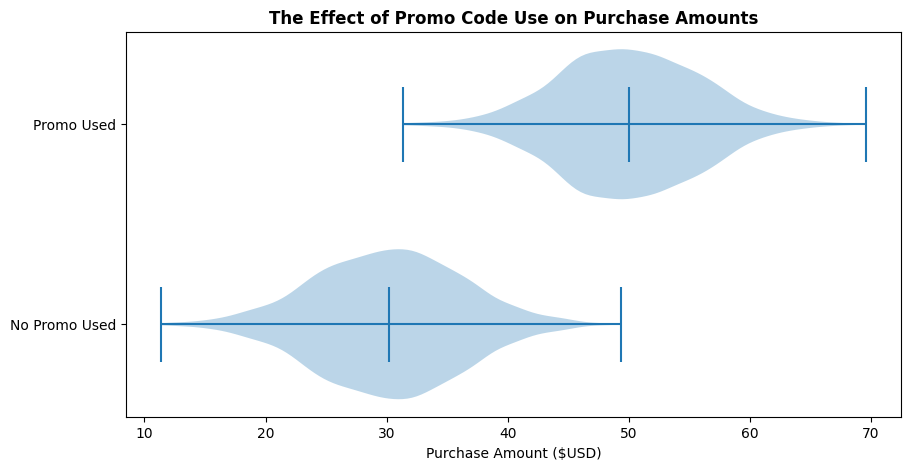

In [135]:
plt.figure(figsize=(10,5))
plt.title('The Effect of Promo Code Use on Purchase Amounts', weight='bold')
plt.violinplot([no_promo_df, yes_promo_df], widths=0.75,
               orientation='horizontal', showmeans=True, 
               showextrema=True)
plt.yticks([1, 2], ['No Promo Used', 'Promo Used'])
plt.xlabel('Purchase Amount ($USD)')
plt.show()

It looks like, the use of Promo Codes leads to higher purchase amounts.

Let's conduct a T-Test to see if the difference in their means are statistically significant.

In [129]:
stats.ttest_ind(no_promo_df, yes_promo_df, nan_policy='raise')

TtestResult(statistic=np.float64(-102.64277172140984), pvalue=np.float64(0.0), df=np.float64(3898.0))

The p-value is *zero*, so we reject the null hypothesis, and conclude that there is a statistically significant difference between the sample means. 

We can now safely conclude that the use of Promo Codes leads to higher purchases.

## Identifying When Users Leave a Review

Let's create a binary column documenting whether or not a customer has left a review.

In [156]:
df['Review Exists'] = np.where(df['Review Rating'].isna(), 0, 1)

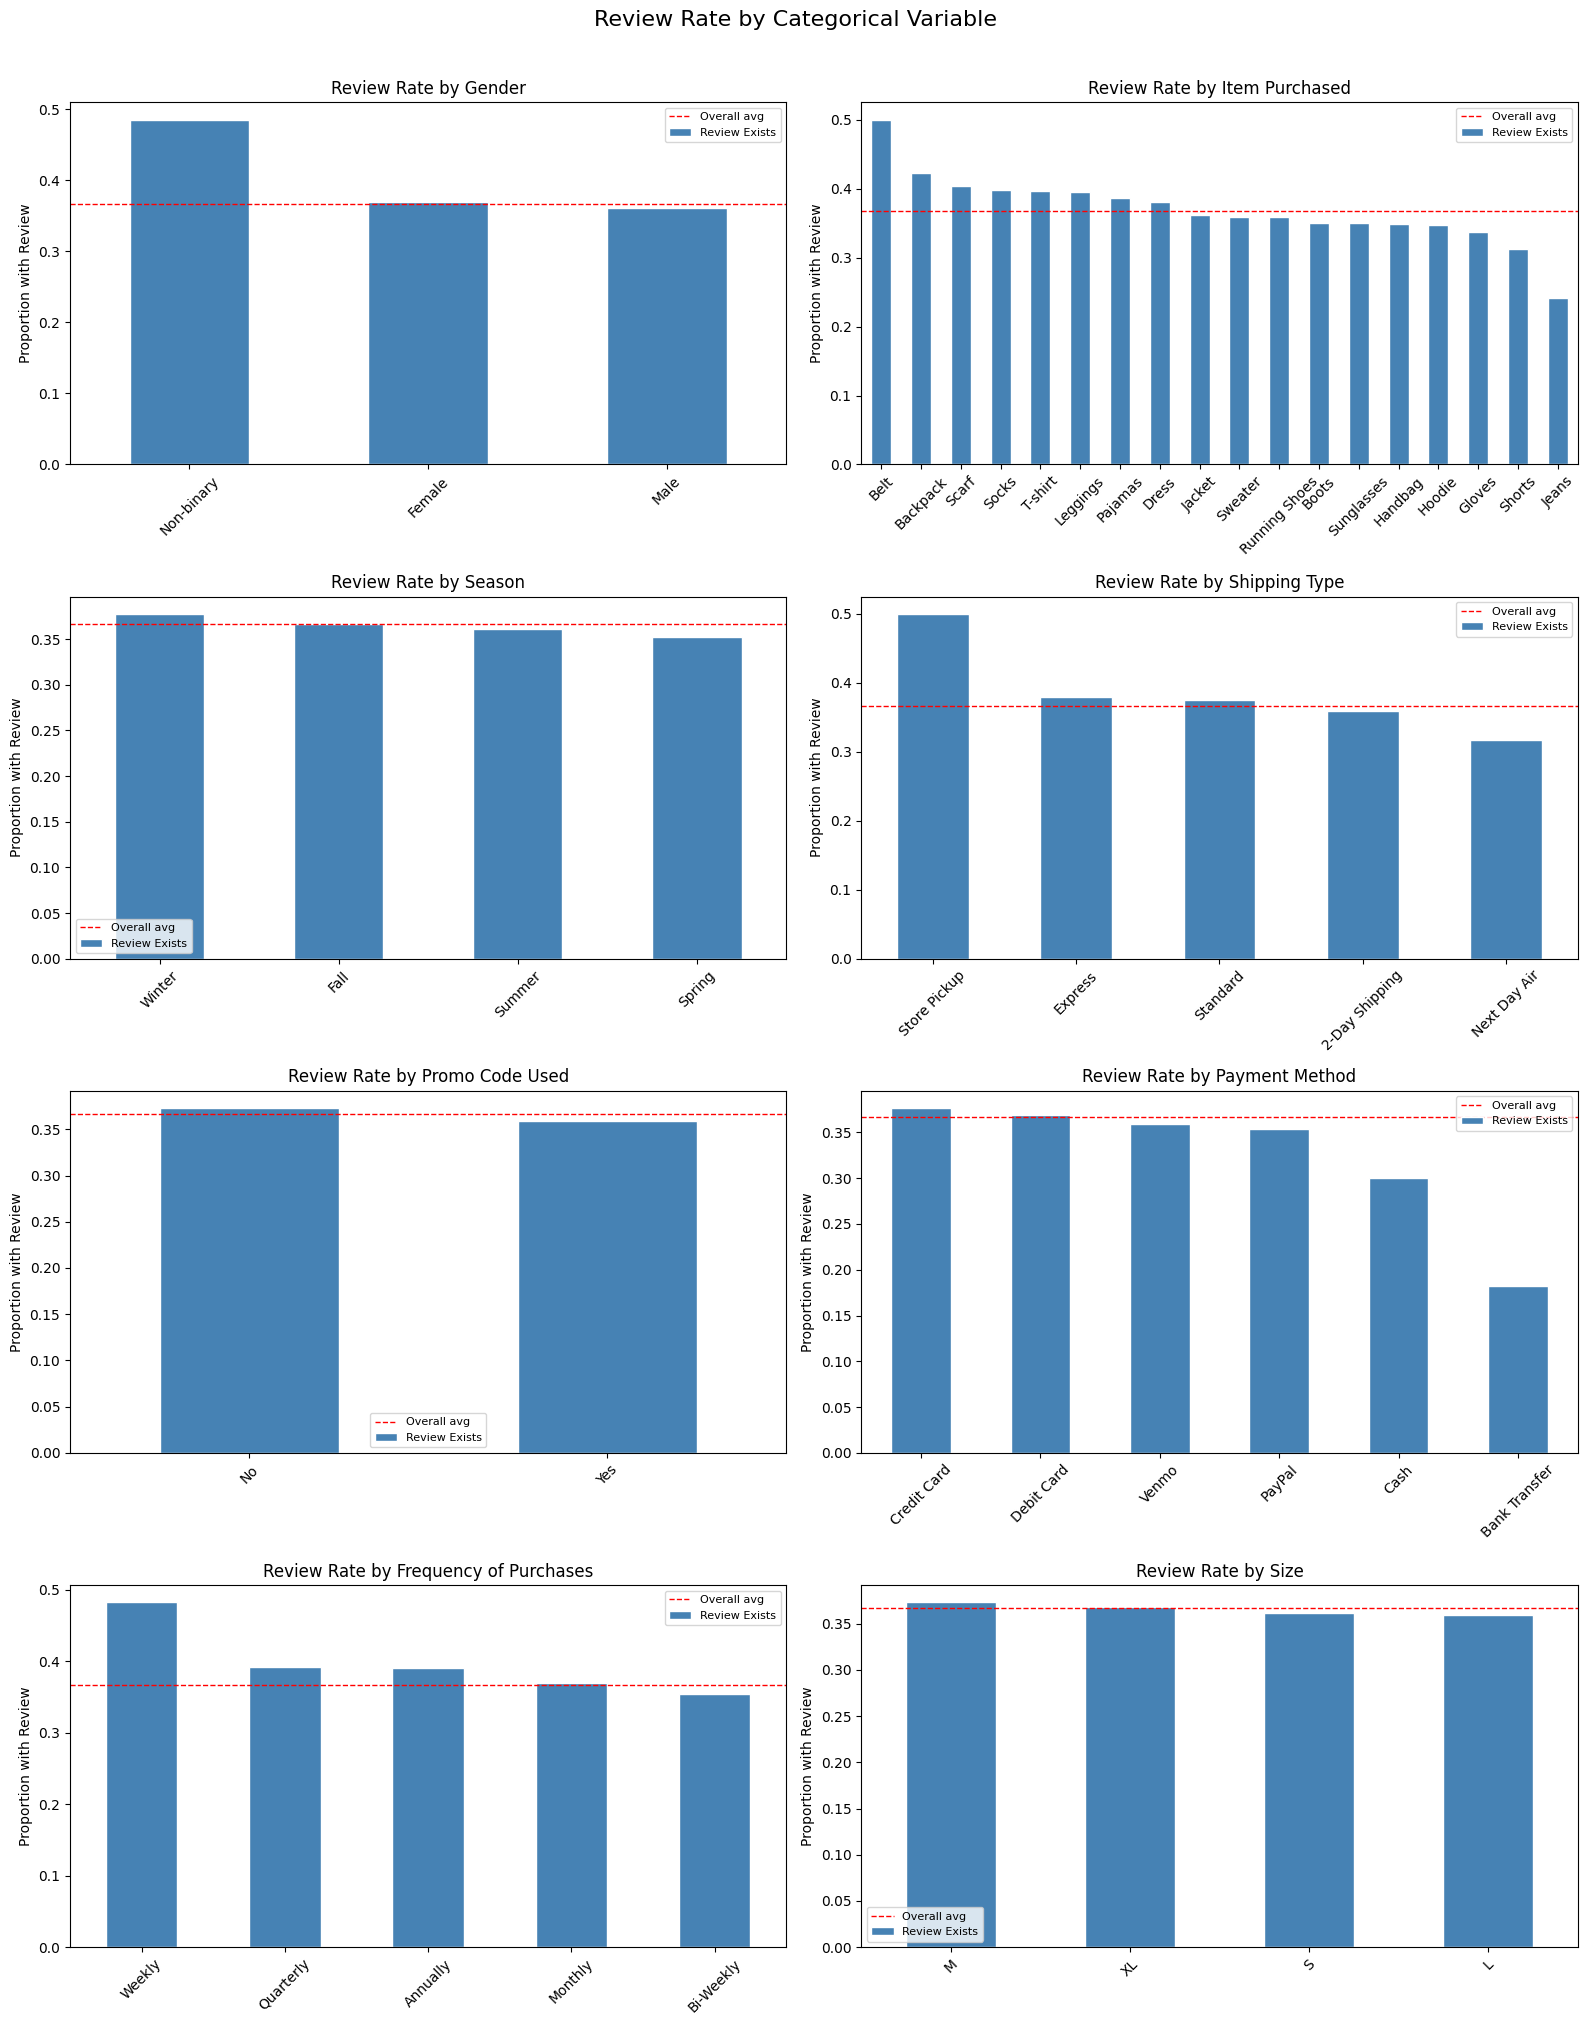

In [158]:
cat_cols = ['Gender', 'Item Purchased', 'Season', 'Shipping Type',
            'Promo Code Used', 'Payment Method', 'Frequency of Purchases', 'Size']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    prop = df.groupby(col)['Review Exists'].mean().sort_values(ascending=False)
    prop.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'Review Rate by {col}')
    axes[i].set_ylabel('Proportion with Review')
    axes[i].set_xlabel('')
    axes[i].axhline(df['Review Exists'].mean(), color='red', linestyle='--', linewidth=1, label='Overall avg')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Review Rate by Categorical Variable', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


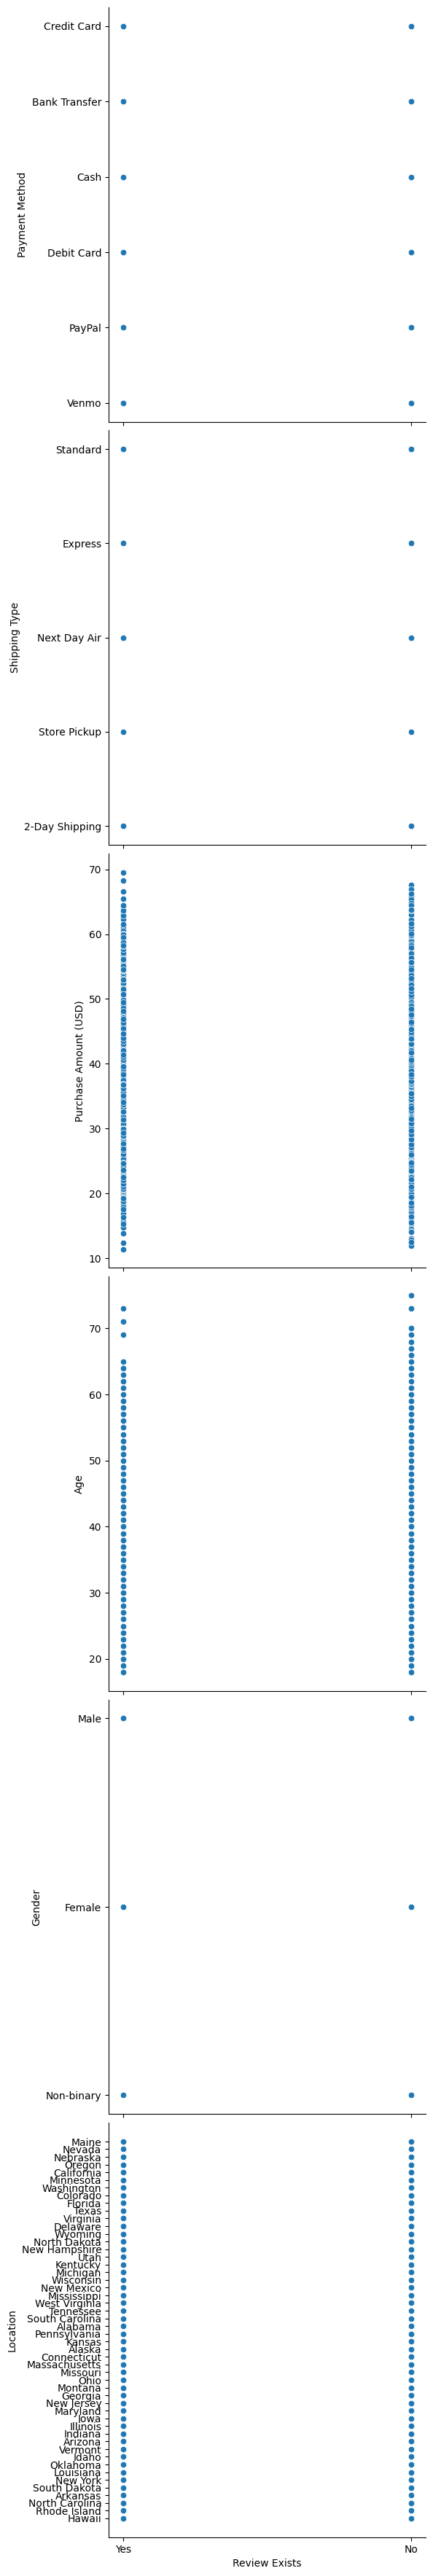

In [154]:
sns.pairplot(df, x_vars=['Review Exists'],
             y_vars=['Payment Method', 'Shipping Type', 'Purchase Amount (USD)', 'Age', 'Gender', 'Location'],
                height=6)
plt.show()

# Answering Additional Analytical Questions

## Age Range of Return Customers

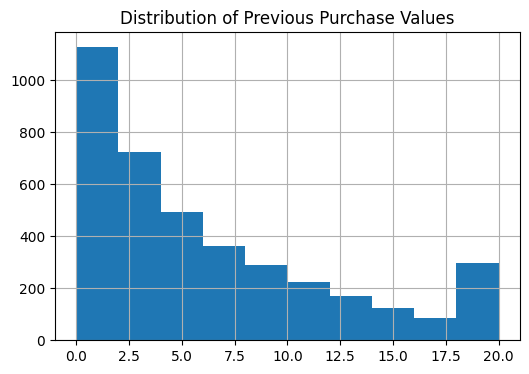

The 75th percentile of Previous Purchases is 9.0
So, we are going to identify the age ranges of customers with Previous Purchases >= 9.0


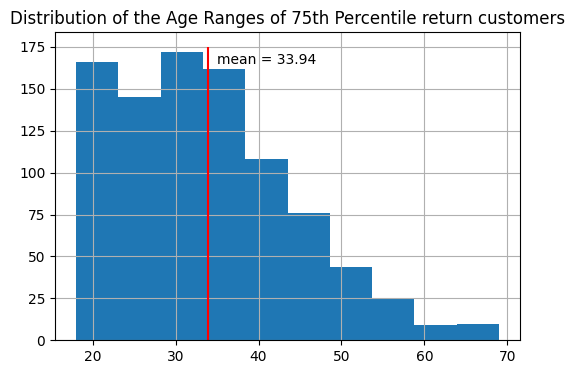

In [69]:
# Histogram plot of previous purchases
plt.figure(figsize=(6,4))
plt.title('Distribution of Previous Purchase Values')
df['Previous Purchases'].hist()
plt.show()

print(f'The 75th percentile of Previous Purchases is {df['Previous Purchases'].quantile(0.75)}')
print(f'So, we are going to identify the age ranges of customers with Previous Purchases >= {df['Previous Purchases'].quantile(0.75)}')

# identifying age patterns in 75th percentile returning customers
plt.figure(figsize=(6,4))
plt.title('Distribution of the Age Ranges of 75th Percentile return customers')
df['Age'][df['Previous Purchases'] >= 9].hist()
plt.vlines(df['Age'][df['Previous Purchases'] >= 9].mean(),0,175, color='red', label='mean')
plt.text(df['Age'][df['Previous Purchases'] >= 9].mean()+1, 165, f'mean = {round(df['Age'][df['Previous Purchases'] >= 9].mean(),2)}')
plt.show()

In [70]:
print('Statistics on the Ages of 75th Percentile return customers')
print(f'Mean Age = {round(df['Age'][df['Previous Purchases'] >= 9].mean(), 2)}')
print(f'Median Age = {df['Age'][df['Previous Purchases'] >= 9].median()}')
print(f'Mode Age = {df['Age'][df['Previous Purchases'] >= 9].mode().to_list()}')
print(f'Q1 Age = {df['Age'][df['Previous Purchases'] >= 9].quantile(0.25)}')
print(f'Q3 Age = {df['Age'][df['Previous Purchases'] >= 9].quantile(0.75)}')

Statistics on the Ages of 75th Percentile return customers
Mean Age = 33.94
Median Age = 33.0
Mode Age = [35.0, 36.0]
Q1 Age = 26.0
Q3 Age = 40.0


In [71]:
# ANSWER
print(f'Returning customers in the TOP 25% of previous purchases are typically {df['Age'][df['Previous Purchases'] >= 9].quantile(0.25)} to {df['Age'][df['Previous Purchases'] >= 9].quantile(0.75)} years old')

Returning customers in the TOP 25% of previous purchases are typically 26.0 to 40.0 years old


## Determining which Regions of the U.S. are Home to Big Spenders

First, let's look at the distribution of spending data


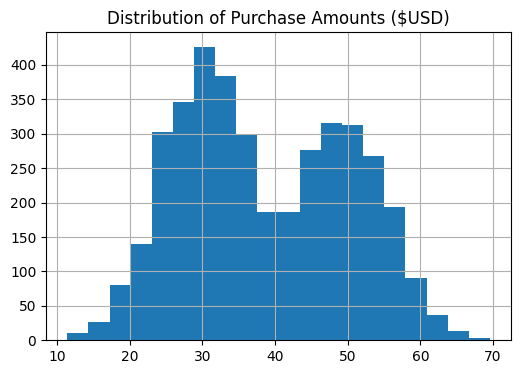

It looks like there's a bimodal split in the data!
Let's confirm this by performing a dip test
Data is multimodal (reject unimodal null hypothesis).


In [72]:
print("First, let's look at the distribution of spending data")
plt.figure(figsize=(6,4))
plt.title('Distribution of Purchase Amounts ($USD)')
df['Purchase Amount (USD)'].hist(bins=20)
plt.show()

print("It looks like there's a bimodal split in the data!")
print("Let's confirm this by performing a dip test")

dip_stat, p_val = diptest(df['Purchase Amount (USD)'])
if p_val < 0.05:
    print("Data is multimodal (reject unimodal null hypothesis).")
else:
    print("Data is unimodal (fail to reject unimodal null hypothesis).")

In [73]:
print("The trough hits it's lowest point at $40, so we'll split the purchases into separate populations there.")

The trough hits it's lowest point at $40, so we'll split the purchases into separate populations there.


In [74]:
df_spenders = df[df['Purchase Amount (USD)'] >= 40]
df_spenders.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,1732.000000,1563.000000,1732.000000,621.000000,1732.000000
mean,977.303695,34.193218,49.972244,3.979066,5.722864
std,712.490276,10.554585,5.601418,1.040105,5.776752
min,1.000000,18.000000,40.006901,1.000000,0.000000
25%,449.750000,26.000000,45.701781,4.000000,1.000000
50%,903.500000,33.000000,49.636449,4.000000,4.000000
75%,1351.250000,41.000000,53.912533,5.000000,9.000000
max,3885.000000,73.000000,69.567481,5.000000,20.000000


In [75]:
df_savers = df[df['Purchase Amount (USD)'] < 40]
df_savers.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,2168.000000,1947.000000,2168.000000,810.000000,2168.000000
mean,2727.979705,34.307653,29.709666,3.848148,5.936347
std,716.868809,10.668092,5.538305,1.151300,5.896242
min,9.000000,18.000000,11.392520,1.000000,0.000000
25%,2180.750000,26.000000,25.793267,4.000000,1.000000
50%,2751.500000,33.000000,30.031277,4.000000,4.000000
75%,3326.250000,41.000000,33.905877,5.000000,9.000000
max,3900.000000,75.000000,39.985166,5.000000,20.000000


In [76]:
print("Let's figure out where these big-spenders tend to reside")

location = []
count = []
for state in df_spenders['Location'].unique(): 
    location.append(state)
    count.append(len(df_spenders[df_spenders['Location'] == state]))
    
spenders_loc_df = pd.DataFrame({'Location': location, 'Count': count})
spenders_loc_df.sort_values(by='Count', ascending=False)

Let's figure out where these big-spenders tend to reside


,Location,Count
25,Indiana,46
20,Nevada,40
24,West Virginia,39
46,California,38
3,Maryland,38
14,South Carolina,38
33,Idaho,37
17,Iowa,37
44,Minnesota,37
23,Arkansas,37


In [77]:
print(f"Most big spenders live in {spenders_loc_df.sort_values(by='Count', ascending=False)['Location'].iloc[0]}!")

Most big spenders live in Indiana!


### Let's see where Savers tend to Reside

For fun, let's see where savers tend to live.

In [78]:
location = []
count = []
for state in df_savers['Location'].unique(): 
    location.append(state)
    count.append(len(df_savers[df_savers['Location'] == state]))
    
savers_loc_df = pd.DataFrame({'Location': location, 'Count': count})
savers_loc_df.sort_values(by='Count', ascending=False)

,Location,Count
5,California,53
25,Alabama,51
12,Delaware,49
33,Montana,48
43,Illinois,47
40,Vermont,46
44,Louisiana,45
10,Texas,45
0,Maine,44
29,Connecticut,44


In [79]:
print(f"Most savers live in {savers_loc_df.sort_values(by='Count', ascending=False)['Location'].iloc[0]}!")

Most savers live in California!
